# I/O

> input/output management

In [ ]:
#| default_exp io

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
import time
import re

# =================================
# Scientific / data
# =================================
import h5py
import numpy as np
import xarray as xr

# =================================
# Bioimage IO
# =================================
from bioio import BioImage as AICSImage
from bioio import Writer as writer
from bioio_tifffile import Reader as TiffReader
from bioio_ome_tiff import Reader as OmeTiffReader
from bioio_czi import Reader as CziReader
from bioio_imageio import Reader as IOReader

# =================================
# Medical imaging
# =================================
from torchio import ScalarImage

# =================================
# fastai
# =================================
from fastai.data.all import *
from fastai.vision.all import *

# =================================
# MONAI
# =================================
from monai.transforms import LoadImage, LoadImaged, SaveImage, SaveImaged
from monai.data.image_reader import ImageReader
from collections.abc import Callable, Iterable, Sequence
from monai.config import PathLike
from monai.data import MetaTensor
from monai.data.utils import is_supported_format
from monai.utils import MetaKeys

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *

In [ ]:
#| export
ScalarImage = ScalarImage

---

### ScalarImage

```python

def ScalarImage(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):


```

*Image whose pixel values represent scalars.*

Example:

    >>> import torch
    >>> import torchio as tio
    >>> # Loading from a file
    >>> t1_image = tio.ScalarImage('t1.nii.gz')
    >>> dmri = tio.ScalarImage(tensor=torch.rand(32, 128, 128, 88))
    >>> image = tio.ScalarImage('safe_image.nrrd', check_nans=False)
    >>> data, affine = image.data, image.affine
    >>> affine.shape
    (4, 4)
    >>> image.data is image[tio.DATA]
    True
    >>> image.data is image.tensor
    True
    >>> type(image.data)
    torch.Tensor

See :class:`~torchio.Image` for more information.

## Image Writers

In [ ]:
#| export

def write_image(data, file_path, dimension_order="TCZYX"):
    """
    Writes an image to a file.

    :param data: Image data (numpy array, tensor, or AICSImage)
    :param file_path: Path to save the image
    :param format: Format to save the image in (default is png)
    """
    if isinstance(data, torchTensor):
        data = data.numpy()
    elif isinstance(data, AICSImage):
        data = data.data

    if not isinstance(data, np.ndarray):
        raise ValueError("Unsupported data type. Expected numpy array, tensor, or AICSImage.")

    try:
        # file_path = file_path + '.' + format
        writer.save(data, file_path, dimension_order)
        print(f"Image successfully saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while saving the image: {e}")


In [ ]:

# Example usage:
numpy_array = np.random.rand(3, 100, 100)
write_image(numpy_array, './data_examples/output_from_numpy.tiff')

metatensor = torch.rand(3, 100, 100)
write_image(metatensor, './data_examples/output_from_tensor.tiff')

aics_image = AICSImage('./data_examples/example_tiff.tiff')
write_image(aics_image, './data_examples/output_from_tiff.png')

Attempted file (/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


Image successfully saved to ./data_examples/output_from_numpy.tiff
Image successfully saved to ./data_examples/output_from_tensor.tiff
Image successfully saved to ./data_examples/output_from_tiff.png


In [ ]:
show_doc(SaveImage)

---

### SaveImage

```python

def SaveImage(
    output_dir:PathLike='./', output_postfix:str='trans', output_ext:str='.nii.gz',
    output_dtype:DtypeLike | None=float32, resample:bool=False, mode:str='nearest', padding_mode:str=border,
    scale:int | None=None, dtype:DtypeLike=float64, squeeze_end_dims:bool=True, data_root_dir:PathLike='',
    separate_folder:bool=True, print_log:bool=True, output_format:str='',
    writer:type[image_writer.ImageWriter] | str | None=None, channel_dim:int | None=0,
    output_name_formatter:Callable[[dict, Transform], dict] | None=None, folder_layout:FolderLayoutBase | None=None,
    savepath_in_metadict:bool=False
)->None:


```

*Save the image (in the form of torch tensor or numpy ndarray) and metadata dictionary into files.*

The name of saved file will be `{input_image_name}_{output_postfix}{output_ext}`,
where the `input_image_name` is extracted from the provided metadata dictionary.
If no metadata provided, a running index starting from 0 will be used as the filename prefix.

Args:
    output_dir: output image directory.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_postfix: a string appended to all output file names, default to `trans`.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_ext: output file extension name.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_dtype: data type (if not None) for saving data. Defaults to ``np.float32``.
    resample: whether to resample image (if needed) before saving the data array,
        based on the ``"spatial_shape"`` (and ``"original_affine"``) from metadata.
    mode: This option is used when ``resample=True``. Defaults to ``"nearest"``.
        Depending on the writers, the possible options are

        - {``"bilinear"``, ``"nearest"``, ``"bicubic"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
        - {``"nearest"``, ``"linear"``, ``"bilinear"``, ``"bicubic"``, ``"trilinear"``, ``"area"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#interpolate

    padding_mode: This option is used when ``resample = True``. Defaults to ``"border"``.
        Possible options are {``"zeros"``, ``"border"``, ``"reflection"``}
        See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
    scale: {``255``, ``65535``} postprocess data by clipping to [0, 1] and scaling
        [0, 255] (``uint8``) or [0, 65535] (``uint16``). Default is ``None`` (no scaling).
    dtype: data type during resampling computation. Defaults to ``np.float64`` for best precision.
        if ``None``, use the data type of input data. To set the output data type, use ``output_dtype``.
    squeeze_end_dims: if ``True``, any trailing singleton dimensions will be removed (after the channel
        has been moved to the end). So if input is (C,H,W,D), this will be altered to (H,W,D,C), and
        then if C==1, it will be saved as (H,W,D). If D is also 1, it will be saved as (H,W). If ``False``,
        image will always be saved as (H,W,D,C).
    data_root_dir: if not empty, it specifies the beginning parts of the input file's
        absolute path. It's used to compute ``input_file_rel_path``, the relative path to the file from
        ``data_root_dir`` to preserve folder structure when saving in case there are files in different
        folders with the same file names. For example, with the following inputs:

        - input_file_name: ``/foo/bar/test1/image.nii``
        - output_postfix: ``seg``
        - output_ext: ``.nii.gz``
        - output_dir: ``/output``
        - data_root_dir: ``/foo/bar``

        The output will be: ``/output/test1/image/image_seg.nii.gz``

        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    separate_folder: whether to save every file in a separate folder. For example: for the input filename
        ``image.nii``, postfix ``seg`` and ``folder_path`` ``output``, if ``separate_folder=True``, it will be
        saved as: ``output/image/image_seg.nii``, if ``False``, saving as ``output/image_seg.nii``.
        Default to ``True``.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    print_log: whether to print logs when saving. Default to ``True``.
    output_format: an optional string of filename extension to specify the output image writer.
        see also: ``monai.data.image_writer.SUPPORTED_WRITERS``.
    writer: a customised ``monai.data.ImageWriter`` subclass to save data arrays.
        if ``None``, use the default writer from ``monai.data.image_writer`` according to ``output_ext``.
        if it's a string, it's treated as a class name or dotted path (such as ``"monai.data.ITKWriter"``);
        the supported built-in writer classes are ``"NibabelWriter"``, ``"ITKWriter"``, ``"PILWriter"``.
    channel_dim: the index of the channel dimension. Default to ``0``.
        ``None`` to indicate no channel dimension.
    output_name_formatter: a callable function (returning a kwargs dict) to format the output file name.
        If using a custom ``monai.data.FolderLayoutBase`` class in ``folder_layout``, consider providing
        your own formatter.
        see also: :py:func:`monai.data.folder_layout.default_name_formatter`.
    folder_layout: A customized ``monai.data.FolderLayoutBase`` subclass to define file naming schemes.
        if ``None``, uses the default ``FolderLayout``.
    savepath_in_metadict: if ``True``, adds a key ``"saved_to"`` to the metadata, which contains the path
        to where the input image has been saved.

In [ ]:
#| export
SaveImage = SaveImage
SaveImaged = SaveImaged

## Image Loaders

It uses helper functions to load and preprocess biological images.

### Utils

In [ ]:
#| export
def tiff2torch(file_path: str):
    '''
    Load tiff into pytorch tensor
    '''
    import tifffile as tiff
    
    img = np.array(tiff.imread(file_path))
    return torch_from_numpy(img)

In [ ]:
#| hide
# Test tiff2torch with existing example tiff file
res_tensor = tiff2torch('./data_examples/example_tiff.tiff')

# Verify object type and expected spatial dimensions
test_eq(isinstance(res_tensor, torch.Tensor), True)
test_eq(res_tensor.shape[-2:], (512, 512))

In [ ]:
#| export
def string2dict(s: str) -> dict[str, int | slice | None]:
    """
    Parse layout strings with:
        - sizes: C2
        - slices: Y[100:200]
        - steps:  Y[100:200:2]

    Returns:
        dict[str, int | slice | None]
    """

    result = {}

    pattern = re.findall(
        r"([A-Za-z])"               # axis
        r"(\d+)?"                   # optional size
        r"(?:\[(\d*):(\d*):?(\d*)\])?",  # optional slice w/ step
        s
    )

    for axis, size, start, stop, step in pattern:
        axis = axis.upper()

        # -------------------------
        # slice case
        # -------------------------
        if start or stop or step:
            slc = slice(
                int(start) if start else None,
                int(stop) if stop else None,
                int(step) if step else None,
            )
            result[axis] = slc

        # -------------------------
        # size case
        # -------------------------
        elif size:
            result[axis] = int(size)

        # -------------------------
        # empty axis
        # -------------------------
        else:
            result[axis] = None

    return result

In [ ]:
#| hide
# Test string2dict with slices, sizes and empty steps
res_dict = string2dict("X[10:20:2]Z0C2")

test_eq(res_dict['X'], slice(10, 20, 2))
test_eq(res_dict['Z'], 0)
test_eq(res_dict['C'], 2)
print(res_dict)

{'X': slice(10, 20, 2), 'Z': 0, 'C': 2}


In [ ]:
#| export
def split_path(file_path, # The path to the file to split
                   exts:(L, list)=['.ome.tiff', '.tiff', '.tif', '.png'] # List of filename extensions 
                   ):
    img_ext = [ext for ext in exts if ext in file_path]
    if img_ext == []:
        return file_path, dict()
    p = file_path.split(img_ext[0])
    if len(p) == 1 or p[1] == '':
        return file_path, dict()
    else:
        path = p[0] + img_ext[0]
        ind_dict = string2dict(p[1])
    return path, ind_dict

In [ ]:
#| hide
# Test split_path with an embedded layout string
path, ind = split_path('./data_examples/example_ome_tiff.ome.tiff/X[10:20:2]Z0')

test_eq(path, './data_examples/example_ome_tiff.ome.tiff')
test_eq(ind['X'], slice(10, 20, 2))
test_eq(ind['Z'], 0)

In [ ]:
split_path('./data_examples/example_ome_tiff.ome.tiff/X[10:20:2]Z0')

('./data_examples/example_ome_tiff.ome.tiff', {'X': slice(10, 20, 2), 'Z': 0})

In [ ]:
#| export
def is_ome_tiff(path: Path) -> bool:
    return path.suffixes[-2:] == [".ome", ".tiff"]

In [ ]:
#| hide
# Test is_ome_tiff with valid and invalid extensions
test_eq(is_ome_tiff(Path('./data_examples/example_ome_tiff.ome.tiff')), True)
test_eq(is_ome_tiff(Path('./data_examples/example_tiff.tiff')), False)

In [ ]:
#| export
from google_crc32c import value


def _to_serializable(value):
    """
    Expand metadata-like objects into dictionaries recursively.
    """
    # numpy scalar types
    if isinstance(value, np.generic):
        return value.item()
    
    # primitives
    if isinstance(value, (str, int, float, bool, type(None))):
        return value

    # arrays
    if isinstance(value, (np.ndarray, xr.DataArray)):
        return "<array skipped>"

    # dicts
    if isinstance(value, dict):
        return {
            k: _to_serializable(v)
            for k, v in value.items()
        }

    # lists / tuples
    if isinstance(value, (list, tuple)):
        return [_to_serializable(v) for v in value]

    # objects with __dict__
    if hasattr(value, "__dict__"):
        return {
            k: _to_serializable(v)
            for k, v in vars(value).items()
            if not k.startswith("_")
        }

    # attrs/dataclass-like objects
    if hasattr(value, "__slots__"):
        return {
            k: _to_serializable(getattr(value, k))
            for k in value.__slots__
            if hasattr(value, k)
        }

    # fallback
    return str(value)


def get_aics_metadata(obj, skip=None):
    """
    Return expanded metadata dictionary from an AICSImage object.
    """

    default_skip = {
        "data",
        "dask_data",
        "xarray_data",
        "xarray_dask_data",
    }

    if skip is not None:
        default_skip.update(skip)

    attrs = {}

    for attr in dir(obj):

        if attr.startswith("_"):
            continue

        if attr in default_skip:
            continue

        try:
            value = getattr(obj, attr)

            # skip methods/functions
            if callable(value):
                continue

            attrs[attr] = _to_serializable(value)

        except Exception as e:
            attrs[attr] = f"<error: {e}>"

    return attrs

In [ ]:
#| hide
# Test _to_serializable with different data types
test_eq(_to_serializable(np.int64(42)), 42)
test_eq(_to_serializable(np.array([1, 2, 3])), "<array skipped>")
test_eq(_to_serializable({"a": np.float32(1.5)}), {"a": 1.5})

aics_img = AICSImage('./data_examples/example_tiff.tiff')

# Test get_aics_metadata extraction
meta_dict = get_aics_metadata(aics_img)
test_eq(isinstance(meta_dict, dict), True)
test_eq('dims' in meta_dict, True)
test_eq('dtype' in meta_dict, True)

Attempted file (/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


/home/export/personal/miguel/anaconda3/envs/biomonai_latest/lib/python3.11/site-packages/bioio_tifffile/reader.py:164: UserWarning: Could not parse tiff pixel size: 'ResolutionUnit'
  warnings.warn(f"Could not parse tiff pixel size: {e}")


In [ ]:
#| export

def extract_formats(filenames: Sequence[str] | str) -> list[str | None]:
    """
    Extract file format(s) from one or multiple filenames.

    Supports:
        - standard extensions (.nii.gz, .png, .npz)
        - HDF5 internal paths (.hdf5/... or .h5/...)

    Args:
        filenames: single path or sequence of paths.

    Returns:
        List of format strings in uppercase (without dots),
        or None if no suffix is found.
    """

    if isinstance(filenames, (str, Path)):
        filenames = [filenames]

    formats = []

    for name in filenames:
        path_str = str(name).lower()

        # HDF5 special case
        if any(ext in path_str for ext in (".h5", ".hdf5")):
            formats.append("HDF5")
            continue

        # Standard suffixes
        suffixes = Path(name).suffixes
        if suffixes:
            fmt = "".join(suffixes).lstrip(".").upper()
            formats.append(fmt)
        else:
            formats.append(None)

    return formats

In [ ]:
#| hide
# Test extract_formats with different extensions and paths
test_eq(extract_formats('image.png'), ['PNG'])
test_eq(extract_formats(['test.nii.gz', 'data.npz']), ['NII.GZ', 'NPZ'])
test_eq(extract_formats('./data_examples/0450_1.hdf5/clean/10'), ['HDF5'])

In [ ]:
#| export
def _sanitize(obj):
    """
    Convert non-serializable objects into safe representations
    and recursively extract nested transform parameters.
    """

    # dictionaries
    if isinstance(obj, dict):
        return {k: _sanitize(v) for k, v in obj.items()}

    # lists / tuples
    elif isinstance(obj, (list, tuple)):
        return type(obj)(_sanitize(v) for v in obj)

    # classes/types
    elif isinstance(obj, type):
        return obj.__name__

    # numpy dtypes
    elif isinstance(obj, np.dtype):
        return str(obj)

    # nested objects / transforms
    elif hasattr(obj, "__dict__") and not isinstance(obj, (str, int, float, bool)):
        return {
            "__class__": obj.__class__.__name__,
            **{
                k: _sanitize(v)
                for k, v in vars(obj).items()
                if not k.startswith("_")
            },
        }

    # callables
    elif callable(obj):
        return obj.__name__ if hasattr(obj, "__name__") else str(obj)

    # everything else
    else:
        return obj

In [ ]:
#| hide
# Test _sanitize with type, numpy dtype, and callable
def dummy_function(): pass

sample_obj = {
    "class_type": int,
    "numpy_dtype": np.dtype('float32'),
    "callable_fn": dummy_function
}

res_sanitized = _sanitize(sample_obj)
test_eq(res_sanitized['class_type'], 'int')
test_eq(res_sanitized['numpy_dtype'], 'float32')
test_eq(res_sanitized['callable_fn'], {'__class__': 'function'})

### BioIO Formats

In [ ]:
#| export
class bioio_loader():
    
    def __init__(self,
                 ind_dict=None, # Dictionary indicating the channels to load
                 loader=None, # Optional custom reader to use for loading the image
                 channels="CZYX", # The desired channel order for the output data
                 **kwargs,
                ):
        store_attr()
        self.kwargs = kwargs

    def __call__(self, path) -> Any:
        return self.image_reader(path)
    
    def image_reader(self, 
               path, # The file path to the image             
               ):

        """
        Loads an image from the specified path using AICSImage library.

        Parameters:
            path (str): The file path to the image.

        Returns:
            tuple: A tuple containing the image data and its affine transformation matrix.
                The image data is a NumPy array representing the image.
                The affine transformation matrix is a 4x4 NumPy array.
        """

        ind_dict = self.ind_dict
        if ind_dict == None:
            # parse path string
            path, ind_dict = split_path(str(path))
            
        # Support for tiff files    
        path = str(path)
        self.kwargs.setdefault('reconstruct_mosaic', False)
        image_aics = AICSImage(path, reader=self.loader, **self.kwargs)

        # Convert to numpy array    
        data = image_aics.get_image_data(self.channels, **ind_dict)
        # extract metadata
        meta = get_aics_metadata(image_aics)
        # Create an identity affine transformation matrix
        affine = np.eye(4)
        # Return the image data and the affine matrix
        return data, meta, affine


In [ ]:
#| hide
# Test bioio_loader
file_path = 'data_examples/cameraman_noisy.jpg'
test_img, meta, affine = bioio_loader({'Y': slice(0,10)}, channels="CZYX")(file_path)

test_eq(test_img.shape, (1, 1, 10, 225))
test_eq(isinstance(meta, dict), True)
test_eq(affine.shape, (4, 4))

In [ ]:
#| hide
# Test MetaTensor integration with loaded data
a = MetaTensor(x=test_img, affine=affine, meta=meta)

test_eq(a.affine, Tensor(np.eye(4)))
test_eq(isinstance(a.detach().cpu().numpy(), np.ndarray), True)
test_eq(isinstance(a.meta, dict), True)

### Hierarchical Data Format

In [ ]:
#| export
def split_hdf_path(file_path, # The path to the HDF5 file to split
                   hdf5_exts:(L, list)=['.h5','.hdf5'] # List of filename extensions 
                   ):
    hdf5_ext = [ext for ext in hdf5_exts if ext in file_path][0]
    if hdf5_ext == []:
        return file_path, None, None
    p = file_path.split(hdf5_ext)
    if len(p) == 1 or p[1] == '':
        return file_path, None, None
    else:
        path = p[0] + hdf5_ext
        tmp = p[1].split('/')[1:]
        dataset = os.path.join(*tmp[:-1])
        patch = tmp[-1]
    return path, dataset, patch

In [ ]:
#| hide
# Test split_hdf_path with compound and standard paths
h_path, ds, pt = split_hdf_path('data_examples/0450_1.hdf5/clean/10')
test_eq(h_path, 'data_examples/0450_1.hdf5')
test_eq(ds, 'clean')
test_eq(pt, '10')

h_path2, ds2, pt2 = split_hdf_path('data_examples/0450_1.hdf5')
test_eq(h_path2, 'data_examples/0450_1.hdf5')
test_eq(ds2, None)
test_eq(pt2, None)

In [ ]:
#| export
class hdf5_loader():
    def __init__(self,
                 dataset: Optional[str]=None, # The dataset to load
                 patch: Optional[str]=None, # The patch to load from the dataset
                 hdf5_exts: List[str]=['.h5','.hdf5'], # List of filename extensions 
                 channels: str="CYX" # The desired channel layout for the output data
                ):
        store_attr()

    def __call__(self, path) -> Any:
        return self.image_reader(path)
    
    def image_reader(self, 
               path, # The path to the HDF5 file to be read
               ):
        """
        Reads a *.h5 (HDF5 format) file and returns the image data along with an identity affine matrix.

        Parameters:
        path (str): The path to the file to be read.

        Returns:
        tuple: A tuple containing:
            - data (numpy.ndarray): The image data read from the file.
            - affine (numpy.ndarray): A 4x4 identity affine matrix.
        """
        
        # split path
        if self.dataset == None:
            path, dataset, patch = split_hdf_path(path, self.hdf5_exts)
            self.dataset = dataset
            self.patch = patch

        with h5py.File(path, 'r') as file:
                if self.dataset == None: print('List of datasets in this file: \n',list(file.keys())); return None
                else:
                    data = file[self.dataset + '/' + self.patch][:] 
                    meta = dict(file[self.dataset].attrs)
                    if 'patch_location' in file[self.dataset + '/' + self.patch].attrs:
                        meta['patch_location'] = file[self.dataset + '/' + self.patch].attrs['patch_location']

        # adjust data dimensions according to channels layout
        while len(data.shape) < len(self.channels):
            # add absent dimensions assuming missing dimensions are at the beginning
            data = np.expand_dims(data, axis=0)
        if len(data.shape) > len(self.channels):
            # remove absent dimensions assuming that data is in CZYX order and missing dimensions are at the beginning
            data = data[(0,)*(data.ndim - len(self.channels)) + (slice(None),)*len(self.channels)]
                
        # If affine is not in meta dict, create a 4x4 identity affine NumpyArray
        if 'affine' in meta:
            affine = meta['affine']
        else:
            affine = np.eye(4)

        # Return the image data and the affine matrix
        return data, meta, affine


In [ ]:
#| hide
# Test hdf5_loader with explicit dataset and patch keys
file_path = './data_examples/0450_1.hdf5'
dataset_name = 'clean'
patch_num = '10'

loader_fn = hdf5_loader(dataset=dataset_name, patch=patch_num)
im, meta, affine = loader_fn(file_path)

# Verify loaded shape, metadata dictionary, and 4x4 affine matrix
test_eq(im.shape, (1, 96, 96))
test_eq(isinstance(meta, dict), True)
test_eq(affine.shape, (4, 4))

Images can be loaded by explicitly writing dataset name and path number...

In [ ]:
from bioMONAI.visualize import show_image


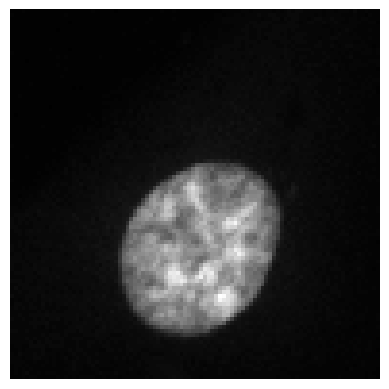

In [ ]:
file_path = './data_examples/0450_1.hdf5'
dataset_name='clean'
patch_num='10'

im , meta, _ = hdf5_loader(dataset=dataset_name, patch=patch_num)(file_path)
show_image(im[0])

In [ ]:
im.shape

(1, 96, 96)

... or enconding them in the path, where datasets are subfolders and patches the image files. The latter being compatible with `image_reader` syntaxis.

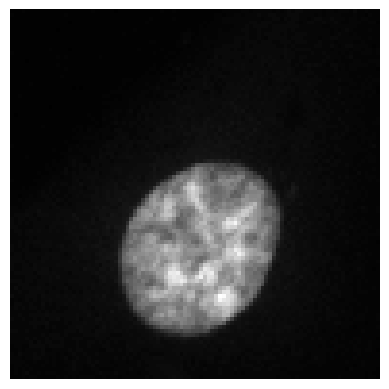

In [ ]:
f = file_path + '/' + dataset_name + '/' + str(patch_num)
im , meta, _ = hdf5_loader()(f)
show_image(im[0])

### Preprocessing

Define classes to store Metadata

In [ ]:
#| export
def _preprocess(obj, transforms=None):
    if transforms is None:
        transforms = []
    elif callable(transforms):
        transforms = [transforms]

    obj.meta['size_original'] = obj.shape

    for t in transforms:
        start = time.time()

        obj = t(obj)

        name = t.__class__.__name__

        raw_params = getattr(t, "__dict__", {})
        safe_params = _sanitize(raw_params)

        obj.meta.setdefault('transforms', {})
        obj.meta['transforms'][name] = {
            'time': time.time() - start,
            'params': safe_params,
        }

    obj.meta['size_after_tfms'] = getattr(obj, "shape", None)

    return obj

In [ ]:
#| hide
from monai.transforms import ScaleIntensity

# Test _preprocess with ScaleIntensity transform
a_copy = MetaTensor(x=test_img, affine=affine, meta=meta.copy())
res_processed = _preprocess(a_copy, [ScaleIntensity()])

# Verify transform records and original vs final sizes
test_eq(len(res_processed.meta['transforms']) > 0, True)
test_eq('ScaleIntensity' in res_processed.meta['transforms'], True)
test_eq(_preprocess(a_copy, None).meta['size_original'], [1, 1, 10, 225])

In [ ]:
#| export
def _preprocess_dict(
    obj: dict,
    transforms: Callable | Iterable[Callable] | None = None,
) -> dict:
    """
    Apply dictionary-based transforms and attach metadata to transformed
    MetaTensor entries.

    This function is designed for MONAI-style dictionary transforms
    (e.g. MapTransform subclasses) that expose a ``keys`` attribute.
    Metadata is stored directly in each transformed MetaTensor under
    ``tensor.meta``.

    Stored metadata includes:
        - ``size_original``:
            Shape before preprocessing.
        - ``transforms``:
            Per-transform timing and parameter information.
        - ``size_after_tfms``:
            Final shape after all transforms.

    Args:
        obj:
            Input dictionary containing MetaTensor objects.
        transforms:
            A callable or iterable of callables operating on dictionaries.

    Returns:
        dict:
            Transformed dictionary with updated MetaTensor metadata.
    """
    if transforms is None:
        transforms = []
    elif callable(transforms):
        transforms = [transforms]

    processed_keys = set()

    for t in transforms:
        keys = getattr(t, "keys", [])

        start = time.time()

        obj = t(obj)

        elapsed = time.time() - start

        for key in keys:
            if key not in obj:
                continue

            tensor = obj[key]

            if not isinstance(tensor, MetaTensor):
                continue

            processed_keys.add(key)

            tensor.meta.setdefault("transforms", {})

            raw_params = getattr(t, "__dict__", {})
            safe_params = _sanitize(raw_params)

            tensor.meta["transforms"][t.__class__.__name__] = {
                "time": elapsed,
                "params": safe_params,
            }

    for key in processed_keys:
        tensor = obj[key]

        if isinstance(tensor, MetaTensor):
            tensor.meta["size_after_tfms"] = tensor.shape 

    return obj

In [ ]:
#| hide
from monai.transforms import ScaleIntensityd

# Test _preprocess_dict using a MONAI dictionary transform
dict_sample = {"image": MetaTensor(x=test_img, affine=affine, meta=meta.copy())}
res_dict = _preprocess_dict(dict_sample, [ScaleIntensityd(keys="image")])

# Verify that metadata and transformed sizes are properly attached
test_eq("ScaleIntensityd" in res_dict["image"].meta["transforms"], True)
test_eq(res_dict["image"].meta["size_after_tfms"], res_dict["image"].shape)

### Loaders registry

In [ ]:
#| export

class LoaderRegistry:
    def __init__(self):
        self._loaders = {}

    def register(self, *suffixes):
        def decorator(fn):
            for s in suffixes:
                self._loaders[s.lower()] = fn
            return fn
        return decorator

    def get(self, path: Path):
        full_suffix = "".join(path.suffixes).lower()
        if full_suffix in self._loaders:
            return self._loaders[full_suffix]
        return self._loaders.get(path.suffix.lower())


LOADER_REGISTRY = LoaderRegistry()

In [ ]:
#| hide
# Test LoaderRegistry registration and retrieval behaviors
registry_test = LoaderRegistry()

@registry_test.register(".png", ".jpg")
def dummy_png_loader(path, **kwargs): return "png_loaded"

# Verify exact and extension-based fallback matches
test_eq(registry_test.get(Path("sample.png")), dummy_png_loader)
test_eq(registry_test.get(Path("sample.jpg")), dummy_png_loader)
test_eq(registry_test.get(Path("sample.txt")), None)

Default loader (AICS only)

In [ ]:
#| export
def _load_default(path, ind_dict=None, loader=None, channels="CZYX", **kwargs):
    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    data, meta, affine = bioio_loader(ind_dict, loader=loader, channels=channels)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)



In [ ]:
#| hide
# Test _load_default output attributes
file_path = 'data_examples/cameraman_noisy.jpg'
res_tensor = _load_default(file_path, {'Y': slice(0,10)}, channels="CZYX")

test_eq(res_tensor.shape, (1, 1, 10, 225))
test_eq(isinstance(res_tensor.meta, dict), True)
test_eq(res_tensor.affine.shape, (4, 4))

### Registered loaders

In [ ]:
#| export
@LOADER_REGISTRY.register(".jpg", ".jpeg")
def _load_jpeg(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load JPG/JPEG images.

    """

    path_str = str(path)

    return _load_default(
        path_str,
        ind_dict=ind_dict,
        loader=IOReader,
        channels=channels,
        **kwargs,
    )

In [ ]:
#| hide
# Test _load_jpeg output attributes
file_path = 'data_examples/cameraman_noisy.jpg'
res_jpeg = _load_jpeg(file_path, channels="CZYX")

test_eq(res_jpeg.shape, (1, 1, 225, 225))
test_eq(isinstance(res_jpeg.meta, dict), True)
test_eq(res_jpeg.affine.shape, (4, 4))

In [ ]:
#| export
@LOADER_REGISTRY.register(".npy")
def _load_npy(path, **kwargs):
    data = np.load(path)
    return MetaTensor(x=data) 


In [ ]:
#| hide
# Test _load_npy format reader
file_path_npy = 'data_examples/matrix_sample.npy'
np.save(file_path_npy, np.random.rand(1, 10, 10))

try:
    res_npy = _load_npy(file_path_npy)
    test_eq(res_npy.shape, (1, 10, 10))
    test_eq(isinstance(res_npy.meta, dict), True)
finally:
    if os.path.exists(file_path_npy): os.remove(file_path_npy)

In [ ]:
#| export
@LOADER_REGISTRY.register(".npz")
def _load_npz(path, **kwargs):
    npz_file = np.load(path)

    key = kwargs.get('npz_key') or next(iter(npz_file.keys()))
    if key not in npz_file:
        raise KeyError(f"Key '{key}' not found. Available: {list(npz_file.keys())}")

    return MetaTensor(x=npz_file[key])



In [ ]:
#| hide
# Test _load_npz format reader
file_path_npz = 'data_examples/matrix_sample.npz'
np.savez(file_path_npz, test_key=np.random.rand(1, 10, 10))

try:
    res_npz = _load_npz(file_path_npz, npz_key='test_key')
    test_eq(res_npz.shape, (1, 10, 10))
    test_eq(isinstance(res_npz.meta, dict), True)
finally:
    if os.path.exists(file_path_npz): os.remove(file_path_npz)

In [ ]:
#| export
@LOADER_REGISTRY.register(".h5", ".hdf5")
def _load_hdf5(path, channels="CZYX", **kwargs):
    path_str = str(path)

    hdf5_ext = [ext for ext in ('.h5', '.hdf5') if ext in path_str]
    path, dataset, patch = split_hdf_path(path_str, hdf5_exts=hdf5_ext)

    data, meta, affine = hdf5_loader(dataset=dataset, patch=patch, hdf5_exts=hdf5_ext, channels=channels)(path)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
# Test _load_hdf5 format reader
file_path_hdf5 = 'data_examples/0450_1.hdf5/clean/10'
res_hdf5 = _load_hdf5(file_path_hdf5, channels="CYX")

test_eq(res_hdf5.shape, (1, 96, 96))
test_eq(isinstance(res_hdf5.meta, dict), True)
test_eq(res_hdf5.affine.shape, (4, 4))

In [ ]:
#| export
@LOADER_REGISTRY.register(".png")
def _load_png(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load a PNG image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """

    kwargs.setdefault('loader', None)

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    channels = channels.replace("C", "S")
    data, meta, affine = bioio_loader(ind_dict, channels=channels, **kwargs)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
# Test _load_png format reader
file_path_png = './data_examples/cameraman_clean.png'
res_png = _load_png(file_path_png, channels="YZX")

test_eq(isinstance(res_png.meta, dict), True)
test_eq(res_png.affine.shape, (4, 4))

In [ ]:
#| export
@LOADER_REGISTRY.register(".tiff", ".tif")
def _load_tiff(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load a TIFF image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    
    # ome.tiff require a separate loader than regular tiff
    if is_ome_tiff(Path(path_str)):
       image_loader = OmeTiffReader
    else:
        image_loader = TiffReader

    data, meta, affine = bioio_loader(ind_dict, loader=image_loader, channels=channels)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
# Test _load_tiff format reader
file_path_tiff = 'data_examples/example_tiff.tiff'
res_tiff = _load_tiff(file_path_tiff, channels="CZYX")

test_eq(res_tiff.shape, (1, 96, 512, 512))
test_eq(isinstance(res_tiff.meta, dict), True)
test_eq(res_tiff.affine.shape, (4, 4))

In [ ]:
#| export
@LOADER_REGISTRY.register(".czi")
def _load_czi(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load a CZI image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """
    
    kwargs.setdefault('use_aicspylibczi', True)
    kwargs.setdefault('include_subblock_metadata', False)

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    
    # bioio-czi needs to operate in aicspylibczi mode to access tiles

    data, meta, affine = bioio_loader(ind_dict=ind_dict,
                                      loader=CziReader, 
                                      channels=channels,
                                      **kwargs,
                                      )(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
# Test _load_czi format reader
file_path_czi = 'data_examples/example_czi.czi'
res_czi = _load_czi(file_path_czi, channels="CZYX")

test_eq(isinstance(res_czi.meta, dict), True)
test_eq(res_czi.affine.shape, (4, 4))

/home/export/personal/miguel/anaconda3/envs/biomonai_latest/lib/python3.11/site-packages/xsdata/formats/dataclass/parsers/utils.py:130: ConverterWarning: Failed to convert value for `Objective.immersion`
  `User Medium` is not a valid `Objective_Immersion`
  warnings.warn(message, ConverterWarning)


In [ ]:
# file_path = './data_examples/3500000523_100X_20170314_D04_P06.czi'
# test_img, meta, affine = bioio_loader({'Y': slice(0,10), 'C': slice(0,2)}, channels="CZYX")(file_path)
# test_eq(test_img.shape, (2, 53, 10, 924))

### Loader resolution


In [ ]:
#| export
def _get_loader(path: Path):
    """
    Select appropriate loader based on file format.

    Priority:
        1. registry-based loader (exact match)
        2. format-based fallback (via extract_formats)
        3. default loader
    """

    # 1. Registry-based detection (fast path)
    loader = LOADER_REGISTRY.get(path)
    if loader:
        return loader

    # 2. Format-based detection (HDF5-aware)
    fmt = extract_formats(path)[0]

    if fmt == "HDF5":
        return _load_hdf5

    # 3. Default fallback
    return _load_default

In [ ]:
#| hide
# Test _get_loader for all registered extensions
test_eq(_get_loader(Path("sample.jpg")), _load_jpeg)
test_eq(_get_loader(Path("sample.jpeg")), _load_jpeg)
test_eq(_get_loader(Path("sample.npy")), _load_npy)
test_eq(_get_loader(Path("sample.npz")), _load_npz)
test_eq(_get_loader(Path("sample.h5")), _load_hdf5)
test_eq(_get_loader(Path("sample.hdf5")), _load_hdf5)
test_eq(_get_loader(Path("sample.png")), _load_png)
test_eq(_get_loader(Path("sample.tiff")), _load_tiff)
test_eq(_get_loader(Path("sample.tif")), _load_tiff)
test_eq(_get_loader(Path("sample.czi")), _load_czi)
test_eq(_get_loader(Path("sample.unknown")), _load_default)

### Load and preprocess

In [ ]:
#| export

def _load_and_preprocess(
    file_path: PathLike,
    transforms: Callable|Iterable[Callable]|None =None,
    channels: str ="CZYX",
    ind_dict: dict|None =None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> MetaTensor:
    """
    Load image and apply preprocessing transforms.

    Also attaches file format metadata.
    """
    path = Path(file_path)

    image_loader = _get_loader(path)
    metatensor = image_loader(path, channels=channels, ind_dict=ind_dict, **kwargs).to(dtype)

    # store path
    metatensor.meta["filepath"] = str(path)
    metatensor.meta["transforms"] = {}

    metatensor = _preprocess(metatensor, transforms)

    # format extraction
    metatensor.meta['format'] = extract_formats(path)[0]
    # save channels info
    metatensor.meta['layout'] = channels

    return metatensor

In [ ]:
#| hide
# Test _load_and_preprocess with tiff and hdf5 layouts
res_yx = _load_and_preprocess('data_examples/example_tiff.tiff', channels="YX")
test_eq(res_yx.shape, (512, 512))

res_slice = _load_and_preprocess('data_examples/example_tiff.tiff', ind_dict={'X': slice(0, 10)})
test_eq(res_slice.shape, (1, 96, 512, 10))

metatensor = _load_and_preprocess(f, channels="CYX")
test_eq(metatensor.data.shape, im.shape)
test_eq(metatensor.meta['size_after_tfms'], im.shape)

/home/export/personal/miguel/anaconda3/envs/biomonai_latest/lib/python3.11/site-packages/bioio_tifffile/reader.py:164: UserWarning: Could not parse tiff pixel size: 'ResolutionUnit'
  warnings.warn(f"Could not parse tiff pixel size: {e}")


In [ ]:
#| export
def _load_and_preprocess_dict(
    obj: dict,
    keys: str | Iterable[str],
    transforms: Callable | Iterable[Callable] | None = None,
    channels: str = "CZYX",
    ind_dict: dict | None = None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> dict:
    """
    Load images from paths stored inside dictionary keys and apply preprocessing.

    Args:
        obj:
            Input dictionary.
        keys:
            Key or iterable of keys containing file paths.
        transforms:
            Callable or iterable of callables.
        channels:
            Channel layout string.
        ind_dict:
            Optional index dictionary.
        **kwargs:
            Optional keyword arguments for the image loader.

    Returns:
        dict:
            Updated dictionary with loaded/preprocessed MetaTensor(s).
    """
    if isinstance(keys, str):
        keys = [keys]

    # load images into dict first
    path_dict = {}
    size_dict = {}
    for key in keys:
        path_dict[key] = Path(obj[key])

        image_loader = _get_loader(path_dict[key])

        obj[key] = image_loader(
            path_dict[key],
            channels=channels,
            ind_dict=ind_dict,
            **kwargs
        ).to(dtype)

        # check default metadata
        obj[key].meta.setdefault("filepath", '')
        obj[key].meta.setdefault("size_original", None)
        obj[key].meta.setdefault("transforms", {})
        obj[key].meta.setdefault("size_after_tfms", None)

        # store size
        size_dict[key] = obj[key].shape

    # apply dict-aware preprocessing (handles metadata internally)
    obj = _preprocess_dict(obj, transforms)

    # attach non-transform metadata
    for key in keys:
        obj[key].meta["size_original"] = size_dict[key]
        obj[key].meta["filepath"] = str(path_dict[key])
        obj[key].meta["format"] = extract_formats(Path(obj[key].meta["filepath"]))[0]
        obj[key].meta["layout"] = channels

    return obj

In [ ]:
#| hide
# Test _load_and_preprocess_dict setup
data_dict = {'image': 'data_examples/example_tiff.tiff'}
res_dict = _load_and_preprocess_dict(data_dict, keys='image', channels="YX")

test_eq(res_dict['image'].shape, (512, 512))
test_eq(res_dict['image'].meta['format'], "TIFF")
test_eq(res_dict['image'].meta['layout'], "YX")

### Read multichannel data

Lazy Streaming

In [ ]:
#| export

def _multi_sequence_stream(
    image_paths: Sequence[PathLike],
    transforms=None,
    channels="CZYX",
    ind_dict=None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> Iterable[MetaTensor]:
    """
    Lazily yield preprocessed image samples.

    Args:
        image_paths: Iterable of file paths.
        transforms: Optional transforms.
        reader: Optional reader.
        npz_key: Optional NPZ key.

    Yields:
        tuple (image, metadata)
    """
    for p in image_paths:
        yield _load_and_preprocess(
            p,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

In [ ]:
#| hide
# Test _multi_sequence_stream lazy generator
paths = ['data_examples/example_tiff.tiff', 'data_examples/example_tiff.tiff']
stream = _multi_sequence_stream(paths, channels="YX")

samples = list(stream)
test_eq(len(samples), 2)
test_eq(samples[0].shape, (512, 512))

In [ ]:
#| export
def _multi_sequence_stream_dict(
    objs: Sequence[dict],
    keys: str | Iterable[str],
    transforms=None,
    channels: str = "CZYX",
    ind_dict=None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> Iterable[dict]:
    """
    Lazily yield dictionary samples with loaded and preprocessed MetaTensor objects.

    Each yielded item preserves the original dictionary structure, where
    specified keys contain MetaTensor objects instead of file paths.

    Args:
        objs:
            Sequence of input dictionaries containing file paths.
        keys:
            Key or iterable of keys containing file paths.
        transforms:
            Optional transforms applied to loaded tensors.
        loader:
            Optional reader/loader function.
        channels:
            Channel layout string.
        ind_dict:
            Optional index dictionary.
        npz_key:
            Optional NPZ key.

    Yields:
        dict:
            Dictionary with loaded and preprocessed MetaTensor(s).
    """
    if isinstance(keys, str):
        keys = [keys]

    for obj in objs:
        yield _load_and_preprocess_dict(
            obj=obj.copy(),
            keys=keys,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

In [ ]:
#| hide
# Test _multi_sequence_stream_dict lazy generator
dict_list = [{'image': 'data_examples/example_tiff.tiff'}, {'image': 'data_examples/example_tiff.tiff'}]
stream_dict = _multi_sequence_stream_dict(dict_list, keys='image', channels="YX")

samples_dict = list(stream_dict)
test_eq(len(samples_dict), 2)
test_eq(samples_dict[0]['image'].shape, (512, 512))

## Image Readers

### Utils

In [ ]:
#| export
def _stack(
    input_metatensors: Sequence[MetaTensor],
    stack_axis: str = "C",
    channels: str = "CZYX",
    squeeze: bool = True,
) -> MetaTensor:
    """
    Stack a sequence of MetaTensors into a single tensor.
    
    Args:
        input_metatensors: Sequence of MetaTensors to stack.
        stack_axis: Axis along which to stack (e.g., "S" for sequence).
        channels: Desired channel order for output (e.g., "CZYX").
        squeeze: Whether to squeeze singleton dimensions before stacking.
    
    Returns:
        Stacked tensor with metadata from each input tensor indexed by position.
    
    Raises:
        ValueError: If input is empty or invalid parameters provided.
    """
    # Validation
    if not input_metatensors:
        raise ValueError("input_metatensors cannot be empty")
    if not stack_axis or len(stack_axis) != 1:
        raise ValueError(f"stack_axis must be a single character, got {stack_axis!r}")
    if not channels or not all(c in "SCZYX" for c in channels):
        raise ValueError(f"channels must contain valid axis labels, got {channels!r}")
    
    # Squeeze tensors
    processed = [
        t.squeeze() if squeeze else t
        for t in input_metatensors
    ]
    
    # Preserve metadata from each original tensor
    metadata_dict = {i: m.meta for i, m in enumerate(input_metatensors)}
    
    # Case A: stack_axis is new (not in current channels)
    if stack_axis not in channels:
        # Stack along new dimension at position 0
        stacked = torch.stack(processed, dim=0)
        # Update metadata: new axis prepended to layout, plus indexed original metadata
        stacked.meta.update({
            'layout': stack_axis + channels,
            'tensors': metadata_dict
        })
        return stacked
    
    # Case B: stack_axis exists in channels → concatenate along that axis
    axis_idx = channels.index(stack_axis)
    
    # Stack first to add a new dimension, then move it to the target position
    stacked = torch.stack(processed, dim=0)
    
    # Move the stacking dimension to the target axis position
    # (adjust for the fact that we stacked at dim=0)
    target_dim = axis_idx + 1  # +1 because stack added a dimension at position 0
    stacked = torch.moveaxis(stacked, 0, target_dim)
    
    # Flatten the stacking dimension into the target axis
    shape = list(stacked.shape)
    shape[axis_idx:axis_idx+2] = [shape[axis_idx] * shape[axis_idx+1]]
    output = stacked.reshape(shape)
    
    # Update metadata with indexed original metadata
    output.meta.update({
        'layout': channels,
        'tensors': metadata_dict
    })
    
    return output


def _meta_from_layout(shape: tuple[int, ...],           # The shape of the image tensor
                      layout: str                       # The channel layout string (e.g., "CZYX")
                      ) -> dict[str, int | str | None]: # A dictionary containing metadata extracted from the layout, including size, width, height, channels, depth, frames, sequence, mode, and kind.
    """
    Extract metadata from channel layout.
    Args:
        shape: The shape of the image tensor
        layout: The channel layout string (e.g., "CZYX")    
    Returns:
        A dictionary containing metadata extracted from the layout, including size, width, height, channels, depth, frames, sequence, mode, and kind.
     """

    _channel_modes = {1: "L", 3: "RGB"}
    
    if len(shape) != len(layout):
        raise ValueError(f"{shape} vs {layout}")

    axis_map = dict(zip(layout, shape))

    meta = {
        "size_output": tuple(shape),
        "width": axis_map.get("X"),
        "height": axis_map.get("Y"),
        "channels": axis_map.get("C"),
        "depth": axis_map.get("Z"),
        "frames": axis_map.get("T"),
        "sequence": axis_map.get("S"),
        MetaKeys.SPATIAL_SHAPE: tuple(axis_map[ax] for ax in "ZYX" if ax in axis_map),
    }

    # mode
    c = meta["channels"]
    meta["mode"] = (
        "L" if c is None else _channel_modes.get(c, f"multichannel ({c})")
    )

    # kind
    if meta["sequence"] is not None and meta["sequence"] > 1:
        meta["kind"] = "sequence"
    if meta["frames"] is not None and meta["frames"] > 1:
        meta["kind"] = "video"
    elif meta["depth"] is not None and meta["depth"] > 1:
        meta["kind"] = "volume"
    else:
        meta["kind"] = "image"

    if "C" in layout:
        meta[MetaKeys.ORIGINAL_CHANNEL_DIM] = layout.index("C")
    else:
        meta[MetaKeys.ORIGINAL_CHANNEL_DIM] = float("nan")

    return meta


def _to_numpy(x):
    return x.detach().cpu().numpy()


def _extract_meta(
    metatensor: MetaTensor,
    metatensors: Sequence[MetaTensor] | None = None,
):
    if metatensors is None:
        return metatensor.meta

    return {
        i: mt.meta
        for i, mt in enumerate(metatensors)
    }


_OUTPUT_MODES = {
    "metatensor",
    "tensor",
    "tensor+meta",
    "nparray",
    "nparray+meta",
}


def _format_output(
    output: str,
    metatensor: MetaTensor,
    metatensors: Sequence[MetaTensor] | None = None,
):
    """
    Convert MetaTensor outputs into the requested representation.
    """
    if output == "metatensor":
        return metatensor

    if output.startswith("tensor"):
        data = metatensor.as_tensor()

    elif output.startswith("nparray"):
        data = _to_numpy(metatensor)

    else:
        raise ValueError(
            f"Unknown output mode: {output}. "
            f"Expected one of {_OUTPUT_MODES}"
        )

    if output.endswith("+meta"):
        return data, _extract_meta(metatensor, metatensors)

    return data



In [ ]:
#| hide
# Test _stack utility with squeeze=False to preserve dimensions
t1 = MetaTensor(torch.rand(1, 10, 10), meta={'layout': 'CYX'})
t2 = MetaTensor(torch.rand(1, 10, 10), meta={'layout': 'CYX'})

# Case A: Stacking along a new axis (e.g., 'S')
res_new_axis = _stack([t1, t2], stack_axis="S", channels="CYX", squeeze=False)
test_eq(res_new_axis.shape, (2, 1, 10, 10))
test_eq(res_new_axis.meta['layout'], "SCYX")

# Case B: Concatenating/stacking along an existing axis (e.g., 'C')
res_exist_axis = _stack([t1, t2], stack_axis="C", channels="CYX", squeeze=False)
test_eq(res_exist_axis.shape, (2, 10, 10))
test_eq(res_exist_axis.meta['layout'], "CYX")

In [ ]:
#| hide
# Test _meta_from_layout metadata extraction
shape = (1, 96, 512, 512)
layout = "CZYX"

meta_res = _meta_from_layout(shape, layout)
test_eq(meta_res['channels'], 1)
test_eq(meta_res['depth'], 96)
test_eq(meta_res['height'], 512)
test_eq(meta_res['width'], 512)
test_eq(meta_res['kind'], "volume")
test_eq(meta_res['spatial_shape'], (96, 512, 512))

In [ ]:
#| hide
# Test internal output formatting utilities
dummy_tensor = MetaTensor(torch.ones(1, 2, 2), meta={'layout': 'CYX'})

# 1. Test _to_numpy
arr_res = _to_numpy(dummy_tensor)
test_eq(isinstance(arr_res, np.ndarray), True)
test_eq(arr_res.shape, (1, 2, 2))

# 2. Test _extract_meta
meta_single = _extract_meta(dummy_tensor)
test_eq(meta_single['layout'], 'CYX')

meta_multi = _extract_meta(dummy_tensor, metatensors=[dummy_tensor, dummy_tensor])
test_eq(len(meta_multi), 2)
test_eq(meta_multi[0]['layout'], 'CYX')

# 3. Test _format_output mappings
fmt_mt = _format_output("metatensor", dummy_tensor)
test_eq(type(fmt_mt).__name__, "MetaTensor")

fmt_t, meta_t = _format_output("tensor+meta", dummy_tensor)
test_eq(isinstance(fmt_t, torch.Tensor), True)
test_eq(meta_t['layout'], 'CYX')

### Base image reader

In [ ]:
#| export
def image_reader(
    file_path: PathLike | Sequence[PathLike],
    lazy: bool = False,
    output: str = "metatensor",
    transforms: Callable | list[Callable] | None = None,
    channels: str = "CZYX",
    ind_dict: dict | None = None,
    dtype=torch.float32,
    squeeze: bool = False,
    stack_axis: str = "C",
    **kwargs,
) -> (
    MetaTensor
    | np.ndarray
    | tuple[np.ndarray, dict]
    | torch.Tensor
    | tuple[torch.Tensor, dict]
):
    """
    Main entry point for image loading.

    Supports:
        - single-image loading
        - multi-image loading
        - lazy streaming
        - tensor / numpy / MetaTensor outputs
        - configurable stacking layouts

    Parameters
    ----------
    file_path:
        Single image path or sequence of image paths.

    lazy:
        If True and multiple paths are provided, images are streamed
        lazily instead of eagerly loaded.

    output:
        Output representation.

        Supported values:
            - "metatensor"
            - "tensor"
            - "tensor+meta"
            - "nparray"
            - "nparray+meta"

    transforms:
        Optional preprocessing transforms.

    channels:
        Axis layout string describing image dimensions.

    ind_dict:
        Optional indexing dictionary for partial loading.

    dtype:
        Output tensor dtype.

    squeeze:
        Remove singleton dimensions before returning.

    stack_axis:
        Axis used for stacking multi-image inputs.

        If present in `channels`, stacking occurs along that axis.

        Otherwise, a new axis is inserted.

    **kwargs:
        Additional loader-specific arguments.
    """

    if output not in _OUTPUT_MODES:
        raise ValueError(
            f"Unknown output mode: {output}. "
            f"Expected one of {_OUTPUT_MODES}"
        )

    is_multi = (
        isinstance(file_path, Sequence)
        and not isinstance(file_path, (str, Path))
    )

    def _load(path):
        return _load_and_preprocess(
            path,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

    # =====================================================
    # MULTI-IMAGE CASE
    # =====================================================

    if is_multi:

        if lazy:
            metatensors = _multi_sequence_stream(
                file_path,
                transforms=transforms,
                channels=channels,
                ind_dict=ind_dict,
                dtype=dtype,
                **kwargs,
            )
        else:
            metatensors = [_load(p) for p in file_path]

        metatensor = _stack(
            metatensors,
            stack_axis=stack_axis,
            channels=channels,
            squeeze=squeeze,
        )

        metatensor.meta.update(
            _meta_from_layout(
                metatensor.shape,
                metatensor.meta["layout"],
            )
        )

        return _format_output(
            output=output,
            metatensor=metatensor,
            metatensors=metatensors,
        )

    # =====================================================
    # SINGLE-IMAGE CASE
    # =====================================================

    metatensor = _load(file_path)

    if squeeze:
        metatensor = metatensor.squeeze()

    metatensor.meta.update(
        _meta_from_layout(
            metatensor.shape,
            channels,
        )
    )

    return _format_output(
        output=output,
        metatensor=metatensor,
    )

In [ ]:
#| hide
from monai.transforms import SpatialCrop

# Test image_reader for transformations recording
out_crop = image_reader(f, transforms=[SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))], output="tensor+meta")
test_eq(len(out_crop[1]['transforms']) > 0, True)
test_eq(''.join(out_crop[1]['transforms']), "SpatialCrop")

# Test image_reader single file outputs
t_mt = image_reader(f, output="metatensor")
test_eq(type(t_mt).__name__, "MetaTensor")
test_eq(isinstance(t_mt.meta, dict), True)

arr_np = image_reader(f, output="nparray", channels="CYX")
test_eq(isinstance(arr_np, np.ndarray), True)
test_eq(arr_np.shape, im.shape)

arr_meta, meta_np = image_reader(f, output="nparray+meta", channels="CYX")
test_eq(meta_np["size_original"], im.shape)

t_raw = image_reader(f, channels="CYX")
test_eq(t_raw.shape, im.shape)

t_meta, meta_t = image_reader(f, output="tensor+meta", channels="CYX")
test_eq(meta_t["size_original"], im.shape)

# Test image_reader multi-sequence stacking behavior
arr_multi = image_reader([f, f], output="nparray")
test_eq(arr_multi.shape, (2, 1, 96, 96))

arr_m_meta, metas_np = image_reader([f, f], output="nparray+meta")
test_eq(len(metas_np), 2)

t_multi = image_reader([f, f], output="tensor")
test_eq(t_multi.shape, (2, 1, 96, 96))

t_m_meta, metas_t = image_reader([f, f], output="tensor+meta")
test_eq(len(metas_t), 2)

t_mt_multi = image_reader([f, f], output="metatensor")
test_eq(t_mt_multi.data.shape[0], 2)

t_layout = image_reader([f, f], output="metatensor", channels="ZYX")
test_eq(t_layout.shape, (2, 1, 96, 96))

# Test image_reader with list of dictionary items
d_paths = {"images": ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff']}
t_dict_paths = image_reader(d_paths["images"], output="metatensor", channels="ZYX")
test_eq(t_dict_paths.shape, (2, 96, 512, 512))

In [ ]:
#| export
def image_reader_dict(
    data: dict,
    keys: str | Iterable[str],
    lazy: bool = False,
    output: str = "metatensor",
    transforms: Callable | list[Callable] | None = None,
    channels: str = "CZYX",
    ind_dict: dict | None = None,
    dtype: torch.dtype = torch.float32,
    squeeze: bool = False,
    stack_axis: str = "C",
    **kwargs,
):
    """
    Load images from dictionary keys.

    Supports:
        - single or multi-image entries
        - eager or lazy loading
        - tensor / numpy / MetaTensor outputs
        - metadata preservation

    Parameters
    ----------
    data:
        Input dictionary containing image paths.

    keys:
        Dictionary keys containing image paths or sequences of paths.

    lazy:
        If True, multi-image sequences are streamed lazily.

    output:
        Output representation.

        Supported values:
            - "metatensor"
            - "tensor"
            - "tensor+meta"
            - "nparray"
            - "nparray+meta"

    transforms:
        Optional preprocessing transforms.

    channels:
        Axis layout string.

    ind_dict:
        Optional indexing dictionary.

    dtype:
        Output tensor dtype.

    squeeze:
        Remove singleton dimensions.

    stack_axis:
        Axis used when stacking multi-image inputs.

    **kwargs:
        Additional loader-specific arguments.

    Returns
    -------
    dict
        Dictionary with loaded image objects replacing file paths.
    """

    if output not in _OUTPUT_MODES:
        raise ValueError(
            f"Unknown output mode: {output}. "
            f"Expected one of {_OUTPUT_MODES}"
        )

    if not keys:
        return data.copy()

    if isinstance(keys, str):
        keys = [keys]

    out = data.copy()

    def _load(obj):
        return _load_and_preprocess_dict(
            obj=obj,
            keys=keys,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

    def _iter_multi(dict_list):

        if lazy:
            return _multi_sequence_stream_dict(
                objs=dict_list,
                keys=keys,
                transforms=transforms,
                channels=channels,
                ind_dict=ind_dict,
                dtype=dtype,
                **kwargs,
            )

        return [_load(d) for d in dict_list]

    for k in keys:

        if k not in out:
            continue

        obj = out[k]

        is_multi = (
            isinstance(obj, Sequence)
            and not isinstance(obj, (str, Path))
        )

        # =====================================================
        # MULTI-IMAGE CASE
        # =====================================================

        if is_multi:

            dict_list = [{k: p} for p in obj]

            loaded = _iter_multi(dict_list)

            metatensors = [d[k] for d in loaded]

            metatensor = _stack(
                metatensors,
                stack_axis=stack_axis,
                channels=channels,
                squeeze=squeeze,
            )

            metatensor.meta.update(
                _meta_from_layout(
                    metatensor.shape,
                    metatensor.meta["layout"],
                )
            )

            out[k] = _format_output(
                output=output,
                metatensor=metatensor,
                metatensors=metatensors,
            )

        # =====================================================
        # SINGLE-IMAGE CASE
        # =====================================================

        else:

            loaded = _load({k: obj})

            metatensor = loaded[k]

            if squeeze:
                metatensor = metatensor.squeeze()

            metatensor.meta.update(
                _meta_from_layout(
                    metatensor.shape,
                    channels,
                )
            )

            out[k] = _format_output(
                output=output,
                metatensor=metatensor,
            )

    return out

In [ ]:
#| hide
from monai.transforms import ScaleIntensityd

# Test image_reader_dict with single and multi-sequence keys
dd = {'image': ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff'], 'label': 'a'}
res_dict = image_reader_dict(dd, keys='image', transforms=ScaleIntensityd(keys='image'))

test_eq(type(res_dict['image']).__name__, "MetaTensor")
test_eq(res_dict['image'].shape, (2, 96, 512, 512))
test_eq(res_dict['image'].meta['layout'], "CZYX")
test_eq(res_dict['image'].meta['mode'], "multichannel (2)")
test_eq(res_dict['label'], 'a')

### Runtime reader

In [ ]:
#| export
class BioImageReader(ImageReader):
    def __init__(
        self,
        converter: Callable[[MetaTensor], MetaTensor] | None = None,  # A callable that takes a MetaTensor and returns a MetaTensor
        reverse_indexing: bool = False,
        **kwargs,
    ):
        super().__init__()
        self.converter = converter
        self.reverse_indexing = reverse_indexing
        self.kwargs = kwargs

    # --------------------------------------------------
    def verify_suffix(self, filename:Sequence[PathLike] | PathLike) -> bool:
        suffixes = self._get_supported_suffixes()
        return is_supported_format(filename, suffixes)


    def _get_supported_suffixes(self) -> list[str]:
        """
        Collect supported suffixes from loader registry removing leading dots.
        """
        # Extract keys from the inner registry dictionary and flatten any nested structures
        return [ext.lstrip('.') for ext in LOADER_REGISTRY._loaders.keys()]

    # --------------------------------------------------
    def read(self, data: PathLike | Sequence[PathLike] | np.ndarray, **kwargs) -> MetaTensor:
        kwargs_ = {**self.kwargs, **kwargs}
        
        if len(data) == 1 and isinstance(data, Sequence) and not isinstance(data, (str, Path)):
            data = data[0]

        mt = image_reader(
            data,
            output="metatensor",
            **kwargs_,
        )

        if self.converter:
            mt = self.converter(mt)

        return mt

    # --------------------------------------------------
    def get_data(self, img: MetaTensor) -> tuple[np.ndarray, dict]:

        if self.reverse_indexing and img.ndim >= 2:
            img = MetaTensor(
                x=img.swapaxes(-1, -2),
                meta=img.meta,
            )

        # extract numpy array
        array = img.as_tensor().cpu().numpy()

        # ensure plain dict
        meta = dict(img.meta)

        return array, meta 
    
    def _get_spatial_shape(self, img: MetaTensor):
        m = img.meta
        return tuple(
            v for v in (m.get("width"), m.get("height"), m.get("depth")) if v is not None
        )

In [ ]:
#| hide
# Test BioImageReader initialization and standard reader API methods
imtransforms = [ScaleIntensity(), SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))]
reader = BioImageReader(channels="CZYX", transforms=imtransforms)

# 1. Test read operation
t_reader = reader.read('./data_examples/example_tiff.tiff')
test_eq(t_reader.shape, (1, 1, 5, 5))
test_eq(isinstance(t_reader.meta, dict), True)

# 2. Test get_data unpacker
arr_reader, meta_reader = reader.get_data(t_reader)
test_eq(isinstance(arr_reader, np.ndarray), True)
test_eq(arr_reader.shape, (1, 1, 5, 5))
test_eq(meta_reader, t_reader.meta)

# 3. Test verification methods
test_eq(reader.verify_suffix('sample.tiff'), True)
test_eq(reader._get_spatial_shape(t_reader), (5, 5, 1))

### Image Loaders

In [ ]:
#| export
LoadImage = LoadImage
LoadImaged = LoadImaged

In [ ]:
#| hide
# Test MONAI integration using BioImageReader backend
bio_reader = BioImageReader()

# Test LoadImage with channel enforcement
monai_load = LoadImage(bio_reader, ensure_channel_first=True)
t = monai_load('./data_examples/example_tiff.tiff')
test_eq(t.shape, [1, 96, 512, 512])

# Test get_data array unpacker
out, metadata = bio_reader.get_data(t)
test_eq(type(out), np.ndarray)
test_eq(metadata, t.meta)

# Test LoadImaged dictionary sequence loading
monai_loadd = LoadImaged('image', reader=BioImageReader)
t_dict = monai_loadd({'image': ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff']})
test_eq(type(t_dict['image']).__name__, "MetaTensor")
test_eq(t_dict['image'].shape, (2, 96, 512, 512))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()